<a href="https://colab.research.google.com/github/mykybath/Superstore-Sales-EDA-Project/blob/main/Superstore_Sales_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction

This notebook has been created with the purpose of analysing superstore sales to explore key insights such as best-selling categories, performance across regions and shipping efficiency.

Key business questions:
- Which regions generate the highest sales?
- Which categories and sub-categories perform best?
- which segment leads to more sales?
- Are there shipping patterns affecting performance?
- Order counts of top customers




#Data Loading and Initial Exploration

In [1]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)

zip_path = "SuperstoreSales.zip"
data_dir = "data"

# Extract only if it hasn't already been extracted
if not os.path.exists(f"{data_dir}/train.csv"):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

sales = pd.read_csv(f"{data_dir}/train.csv")

#Brief Overview of Dataset Structure:
- null or duplicated values
- types
- column names
- unique entries


In [2]:
sales.head()
#sales.tail()
#sales.describe(include ='all')
#sales.info()
#sales.shape
#sales.index
#sales.columns
#sales.dtypes
#print(sales.isnull().sum()) #postcode has missing values
#print(sales.duplicated().sum())


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
#identifying unique categories and sub categories
print(sales['Category'].unique())
print(sales['Sub-Category'].unique())
#sales['City'].unique()
#sales['Country'].unique() #only USA listed in dataset - country will be dropped
sales.nunique() #seeing how many unique values for each column

['Furniture' 'Office Supplies' 'Technology']
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


,0
Row ID,9800
Order ID,4922
Order Date,1230
Ship Date,1326
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,529


# Cleaning Dataset

- Postcode has missing values.
- Only one country (USA)
- Will be dropped from dataframe as region and state provide enough granularity for analysis.
- Country will be dropped as only United States in dataframe.
- Row ID and Customer ID not needed for analysis purposes.

In [4]:
sales = sales.copy()
sales = sales.drop(columns=['Postal Code','Customer ID', 'Row ID', 'Country'])
sales.columns = sales.columns.str.lower()
sales.columns = sales.columns.str.replace(' ','_') #replacing spaces with _ allows reproducibility for different analyses
sales.columns #showing updated sales.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'city', 'state', 'region', 'product_id', 'category',
       'sub-category', 'product_name', 'sales'],
      dtype='object')

In [5]:
sales.count() #displays total order count
#sales['Sub_Category'].value_counts(0)
sales['category'].value_counts(0)
sales['customer_name'].value_counts(0)
#displaying order counts for each customer

,count
customer_name,
William Brown,35
Matt Abelman,34
Paul Prost,34
John Lee,33
Jonathan Doherty,32
...,...
Lela Donovan,1
Jocasta Rupert,1
Carl Jackson,1


#Analysis of Regional Sales


/tmp/ipykernel_2082/4196855808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = sales_in_regions,x ='region',y ='sales',palette = 'Set2')


Text(0, 0.5, 'Sales')

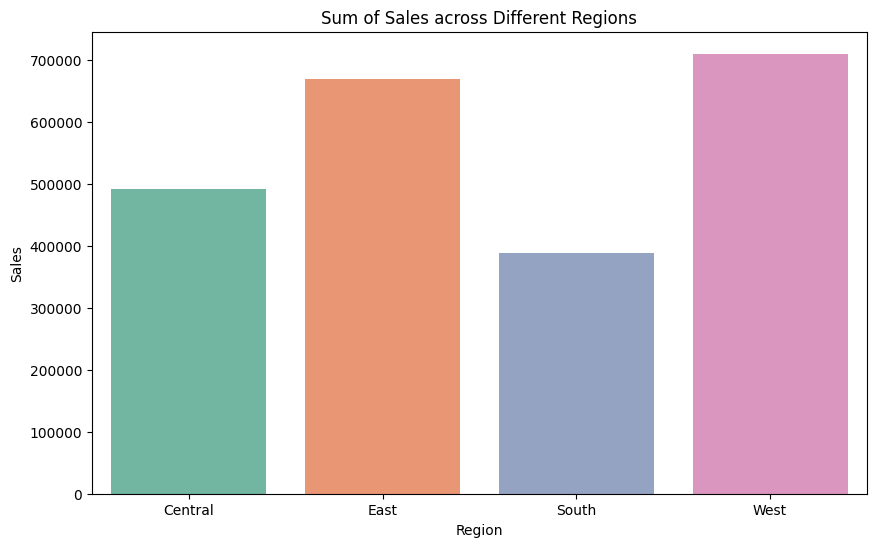

In [6]:
sales_in_regions = sales.groupby(['region'], as_index= False)['sales'].sum(0)
sns.barplot(data = sales_in_regions,x ='region',y ='sales',palette = 'Set2')
avgsales_in_regions = sales.groupby(['region'], as_index = False)['sales'].mean()

plt.title('Sum of Sales across Different Regions')
plt.xlabel('Region')
plt.ylabel('Sales')


- West region generates highest volume of total revenue,
- Followed closely by East region.
- South regions contribute the least to total revenue, generating lower sales.
- Could maximise regional revenue generation by allocating more resources and marketing expenditures to West and East regions where there is more demand.

/tmp/ipykernel_2082/907510485.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Average Sales')

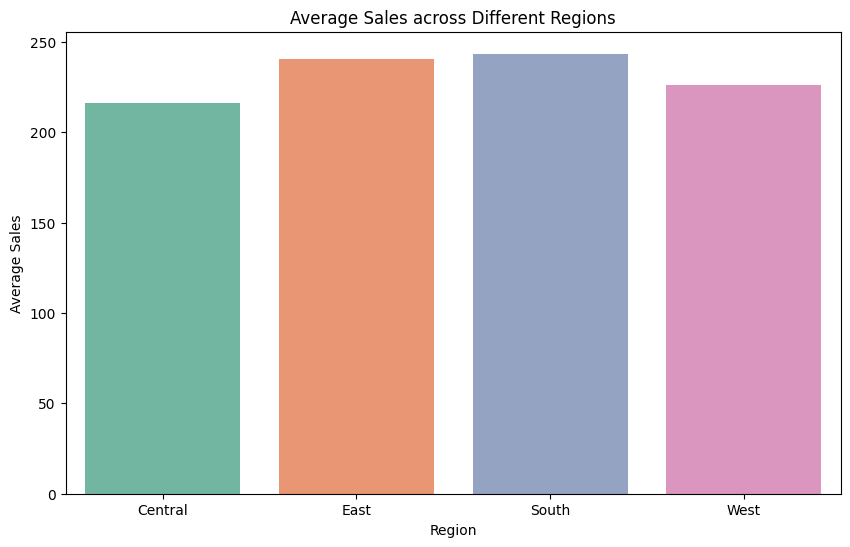

In [7]:
sales_in_regions = sales.groupby(['region'], as_index= False)['sales'].mean()
sns.barplot(
    data = sales_in_regions,
    x ='region',
    y ='sales',
    palette = 'Set2'
)
plt.title('Average Sales across Different Regions')
plt.xlabel('Region')
plt.ylabel('Average Sales')

- Less variance between all regions with all generating average sales of above 200 usd.
- can infer from this that average sales are similar
- customers on average tend to spend in the range of 200 usd.
- East and West regions generated higher revenue, but similar average sales across all regions
- Suggests lower order frequency in South and Central regions leading to lower revenue generation rather than order volume.
- More marketing expenditure within these regions could drive more sales upon accqusition of more customers in South and Central regions.

/tmp/ipykernel_2082/4107397939.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sales, x='region', y='sales', palette='Set2', showfliers=False)


Text(0, 0.5, 'Sales Value')

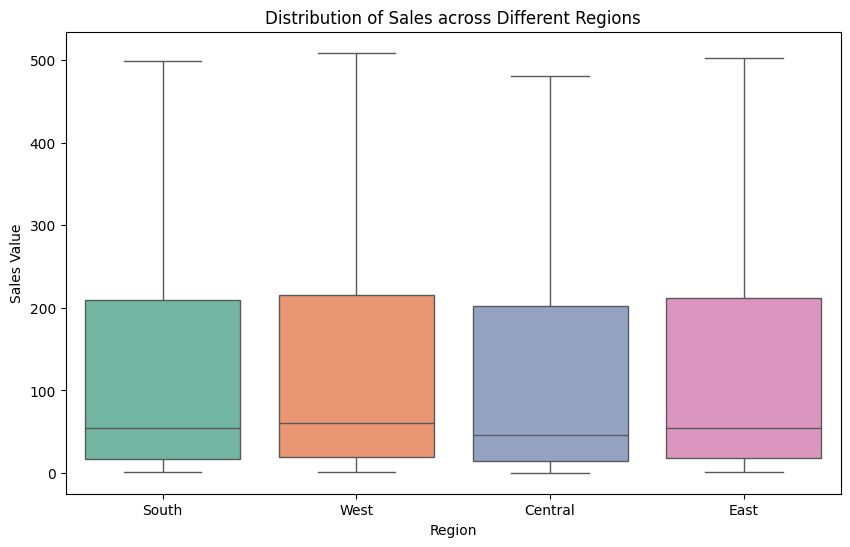

In [8]:
sns.boxplot(data=sales, x='region', y='sales', palette='Set2', showfliers=False)
plt.title('Distribution of Sales across Different Regions')
plt.xlabel('Region')
plt.ylabel('Sales Value')

- Median and IQR values are almost identical across all regions
- All median values of sales being below 100.
- Standard consumer purchases are almost identical, when excluding extreme outliers.
- Suggests standard day to day transactions tend to be within this range of 20-200 usd, can be considered to be highly predictable across all regions.

Text(0, 0.5, 'Frequency')

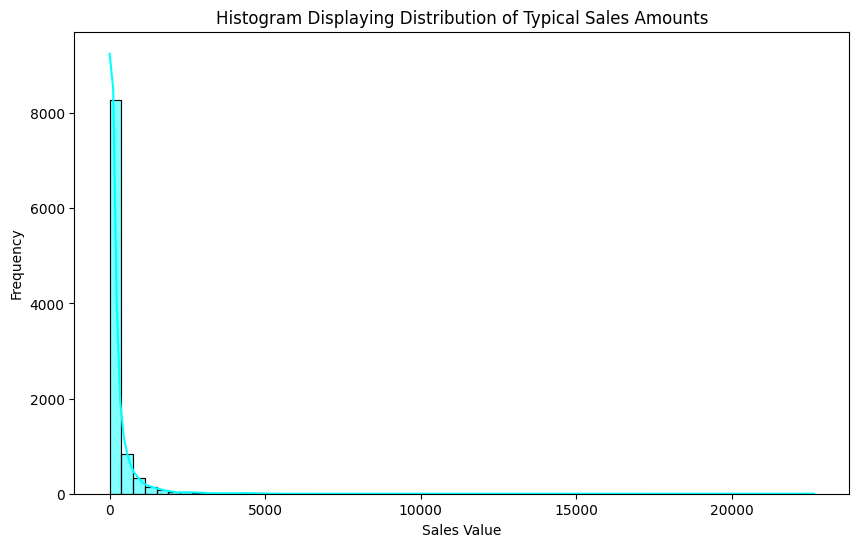

In [9]:
sns.histplot(sales['sales'], bins=60, kde= True, color = 'cyan')
plt.title('Histogram Displaying Distribution of Typical Sales Amounts')
plt.xlabel('Sales Value')
plt.ylabel('Frequency')

- Typical spend/sales value is strongly right skewed
- Long thin tail extends towards high value transactions.
- Very few transactions exceeding 2000 usd.
- Low ticket items sell more frequently in comparison to high ticket items.
- Sales generated are predominantly from high sales volume of items are of low margin.
- Business operates mainly based on the standard consumer.
- Rare high value enterprise transactions drive average sales higher.

In [10]:
customer_orders = sales.groupby(['region','category'], as_index = False)['sales'].mean(numeric_only=True)

Text(0, 0.5, 'Average Sales')

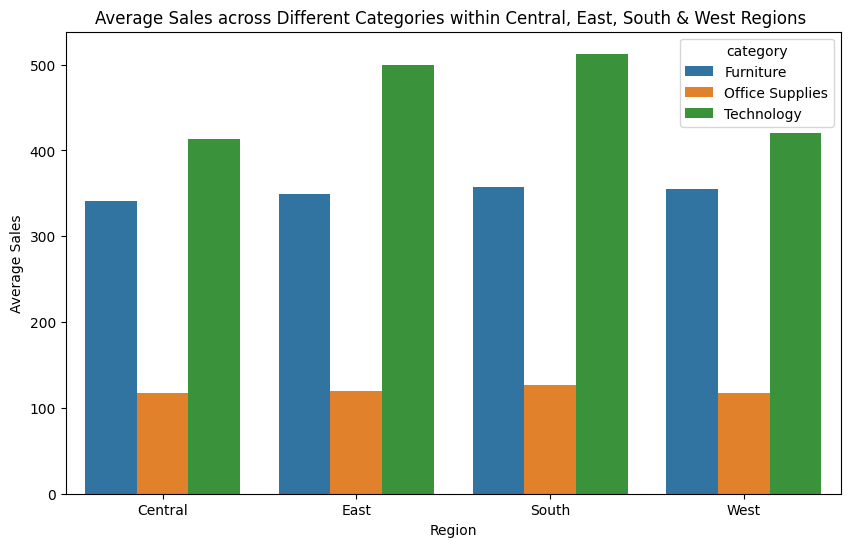

In [11]:
sns.barplot(data = customer_orders, x='region', y='sales', hue ='category')
plt.title('Average Sales across Different Categories within Central, East, South & West Regions ')
plt.xlabel('Region')
plt.ylabel('Average Sales')

- Indicates all regions had a similar ranges of sales for furniture and office supplies.
- East and South regions generated most sales within the technology sector.
- Technology is in high demand as it generates most sales across all regions in comparison to office supplies and furniture.
- Can potentially boost sales by introducing technology packages in west and central regions.


Text(0, 0.5, 'Average Sales')

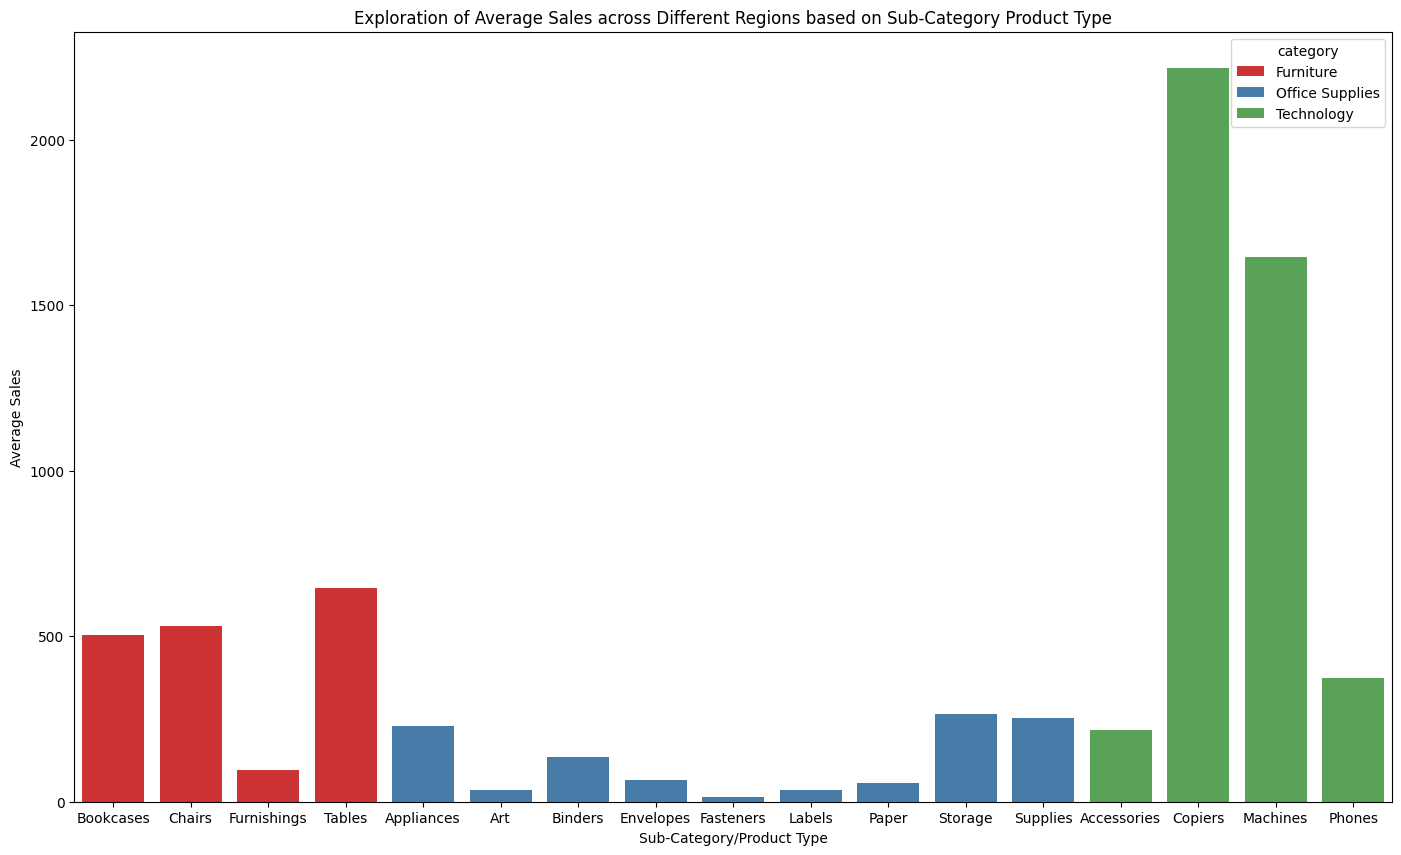

In [12]:
plt.figure(figsize=(17,10))
category_type = sales.groupby(['category', 'sub-category'], as_index=False)['sales'].mean(numeric_only=True)
sns.barplot(data = category_type, x='sub-category', y='sales', hue ='category', palette='Set1')

plt.title('Exploration of Average Sales across Different Regions based on Sub-Category Product Type')
plt.xlabel('Sub-Category/Product Type')
plt.ylabel('Average Sales')

- Items that generate highest sales for office supplies is storage, with fasteners contributing the lowest.
- Copiers and machines lead to significantly higher average sales in technology sector, perhaps due to being high ticket items.
- Tables generate highest average sales in furnishings category.
- Copiers and machines appear to significantly increase average sales.
- Small inventory bottlenecks could drastically affect average sales.
- Can infer whilst technology is most in demand in Southern region, it is likely low ticket items such as phones and accessories as West and East regions generate more revenue, despite a lower demand for the technology sector (may be more demand for copiers and machines).

#Analysis of Categorical Sales

Text(0, 0.5, 'Sales')

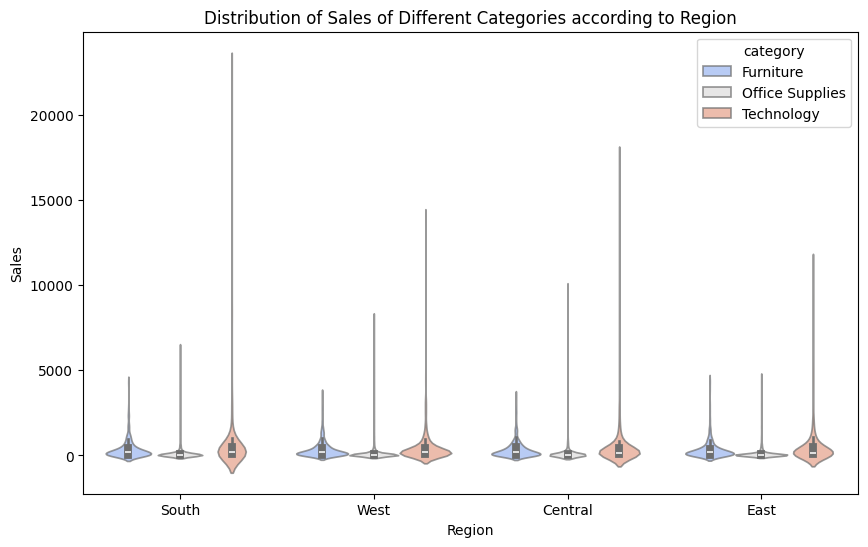

In [13]:
sns.violinplot(data=sales, x='region', y='sales', hue='category', palette='coolwarm', alpha=0.7)
plt.title('Distribution of Sales of Different Categories according to Region')
plt.xlabel('Region')
plt.ylabel('Sales')

- Technology sector has more extreme values demonstrated by longer violin plots
- High value sales occur more frequently in the technology category
- Most likely due to sales of copiers and machines
- Furniture produces higher value sales than office supplies
- Overall, all categories tend to have similar sale values, no matter the region.

#Analysis of Shipping Efficiency and Popularity

In [14]:
#shipdateandmethod = sales.groupby(['ship_date', 'ship_mode'], as_index=False)['sales'].median(numeric_only=True)
#sns.barplot(data=shipdateandmethod, x='ship_mode', y='sales', hue='ship_date')
#NEED TO CREATE NEW COLUMNS TO SEPARATE BY YEAR/PERIODS converting to datetime format to create month, year and quarter columns for cleaner analysis

sales['order_date'] = pd.to_datetime(sales['order_date'], format='%d/%m/%Y')
sales['ship_date'] = pd.to_datetime(sales['ship_date'], format='%d/%m/%Y')

sales['ship_year'] = sales['ship_date'].dt.year
sales['ship_month_name'] = sales['ship_date'].dt.month_name()
sales['ship_month'] = sales['ship_date'].dt.month
sales['ship_quarter'] = sales['ship_date'].dt.quarter

sales['order_year'] = sales['order_date'].dt.year
sales['order_month_name'] = sales['order_date'].dt.month_name()
sales['order_month'] = sales['order_date'].dt.month
sales['order_quarter'] = sales['order_date'].dt.quarter




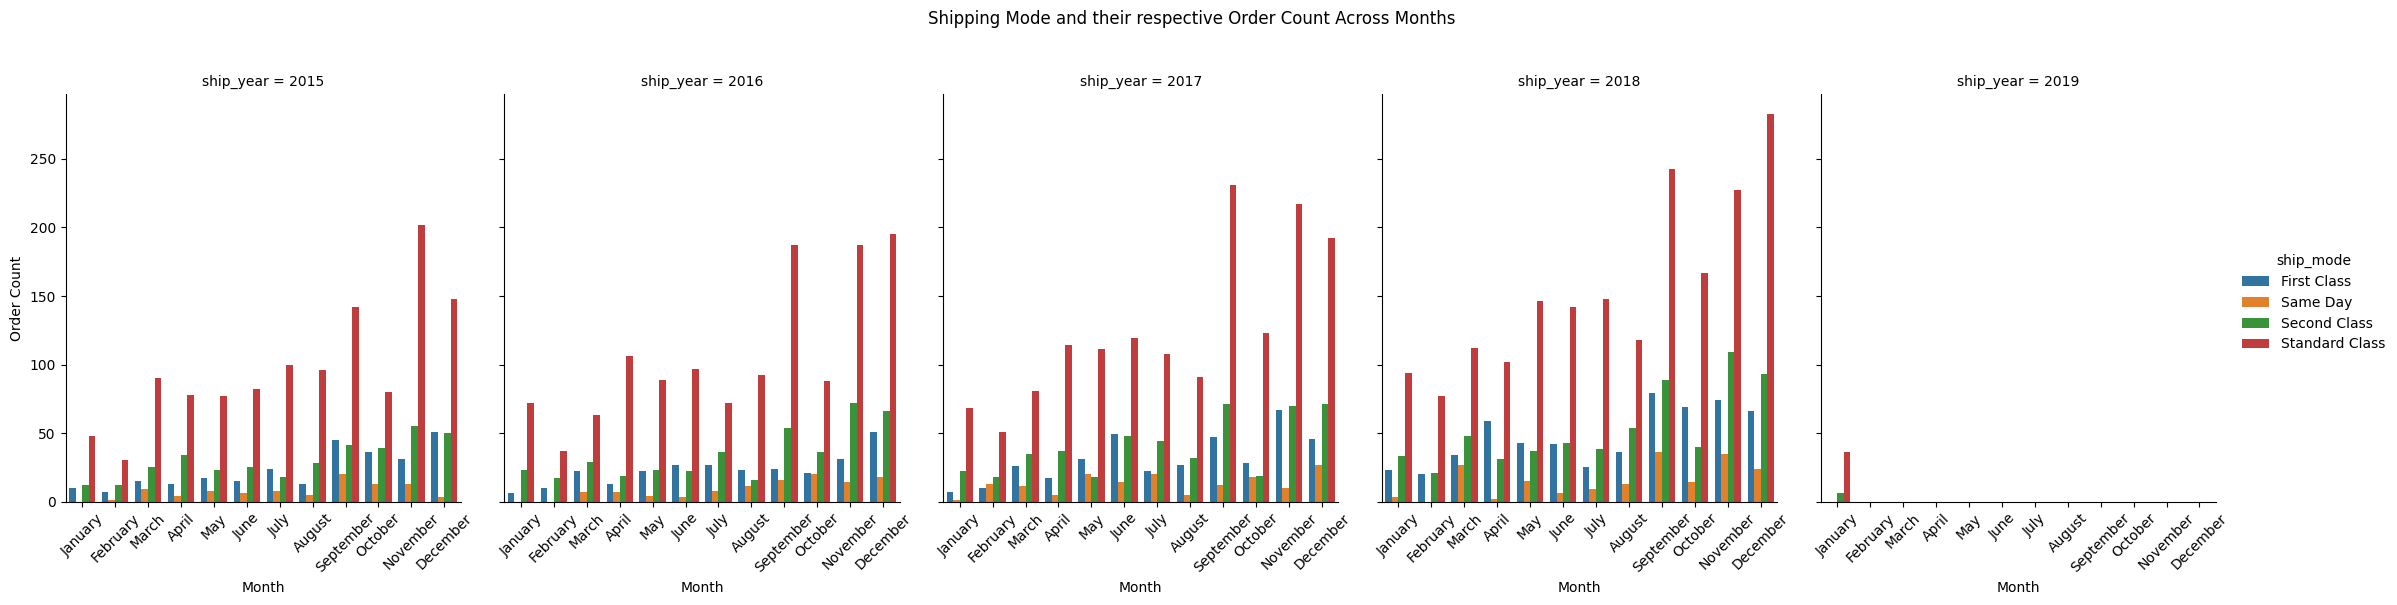

In [15]:

shipmodepop = sales.groupby(['ship_mode', 'ship_month', 'ship_month_name','ship_year'], as_index=False)['sales'].size().rename(columns={'size': 'order_count'})
shipmodepop = shipmodepop.sort_values('ship_month')
g = sns.catplot(data = shipmodepop, x='ship_month_name', y='order_count', hue='ship_mode', col='ship_year', kind ='bar', height = 5, aspect = 0.9)
for ax in g.axes.flat:
    ax.tick_params(axis = 'x', rotation = 45)
    g.set_axis_labels('Month', 'Order Count')
    g.fig.suptitle('Shipping Mode and their respective Order Count Across Months', y = 1.1)

- Standard class is overwhelmingly the most popular shipping method across all months and years.
- Same day is the least popular option.
- First class and second class option increases in popularity in fourth quarter
- This corresponds with the increase in standard class, suggesting this may be due to overall increase in sales within this time period.
- Providing these options of second class, first class and same day does generate higher order frequencies as it is prevalent as the shipping method chosen across all months and years.

In [16]:
sales['shipping_days'] = (sales['ship_date'] - sales['order_date']).dt.days

Text(0, 0.5, 'Shipping Days')

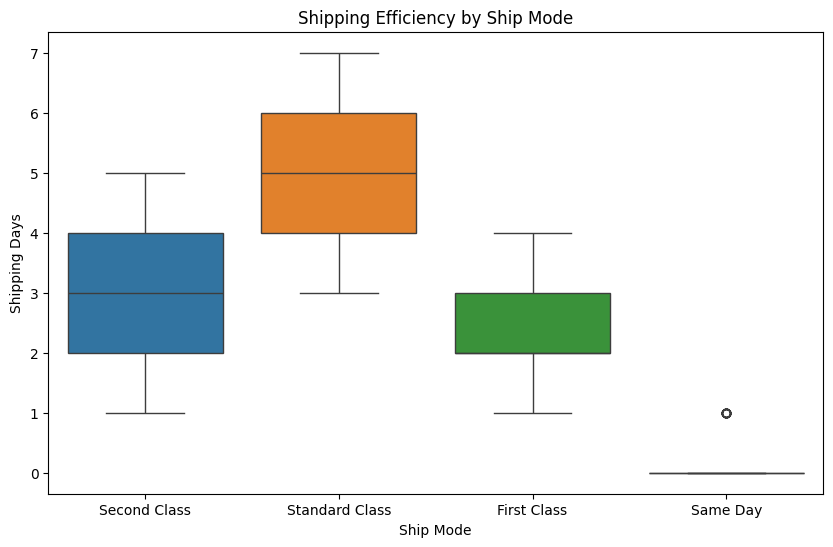

In [17]:
sns.boxplot(data=sales, x='ship_mode', y='shipping_days', hue = 'ship_mode')

plt.title('Shipping Efficiency by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Shipping Days')

- Shipping modes are highly efficient, with all methods having an appropriate range of shipping duration.
- Logistics department is working efficiently, maximised consumer expectations when opting for respective shipping modes.

In [18]:
shipping_monthly = (sales.groupby(['ship_month_name', 'ship_month', 'ship_mode'],as_index=False)['shipping_days'].mean())

shipping_monthly = shipping_monthly.sort_values('ship_month')

Text(0, 0.5, 'Shipping Days')

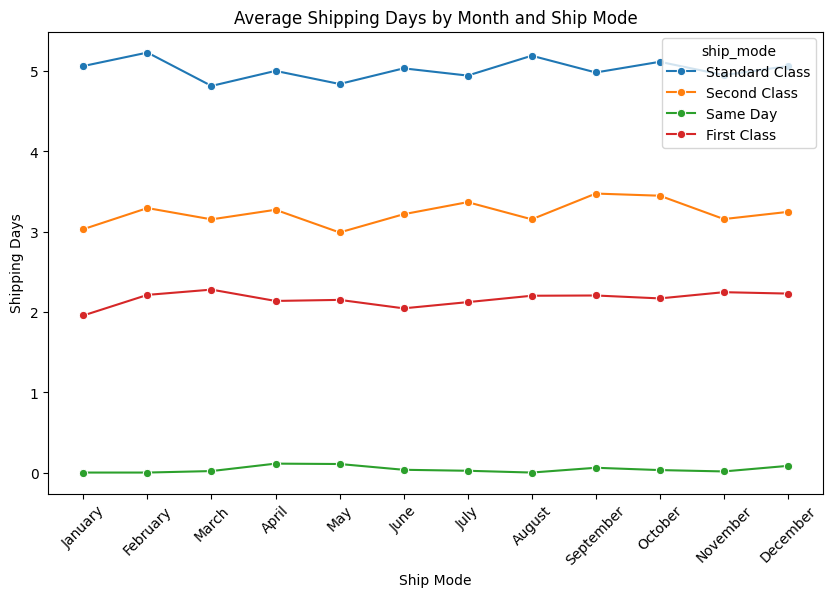

In [19]:
sns.lineplot(data=shipping_monthly,x='ship_month_name',y='shipping_days',hue='ship_mode', marker='o')
plt.xticks(rotation=45)

plt.title('Average Shipping Days by Month and Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Shipping Days')

- Same day delivery is highly efficient, as well as first class.
- There is some variability for second class, but still remains with 3-4 shipping days range.
- Standard class is variable between 4-5 days.
- Logistics department is highly resilient and operates with high efficiency across all months, even when there is increased demand.

#Analysis of General Consumer Activity and Overall Trends

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'William Brown'),
  Text(1, 0, 'Paul Prost'),
  Text(2, 0, 'Matt Abelman'),
  Text(3, 0, 'John Lee'),
  Text(4, 0, 'Seth Vernon'),
  Text(5, 0, 'Chloris Kastensmidt'),
  Text(6, 0, 'Jonathan Doherty'),
  Text(7, 0, 'Arthur Prichep'),
  Text(8, 0, 'Emily Phan'),
  Text(9, 0, 'Zuschuss Carroll')])

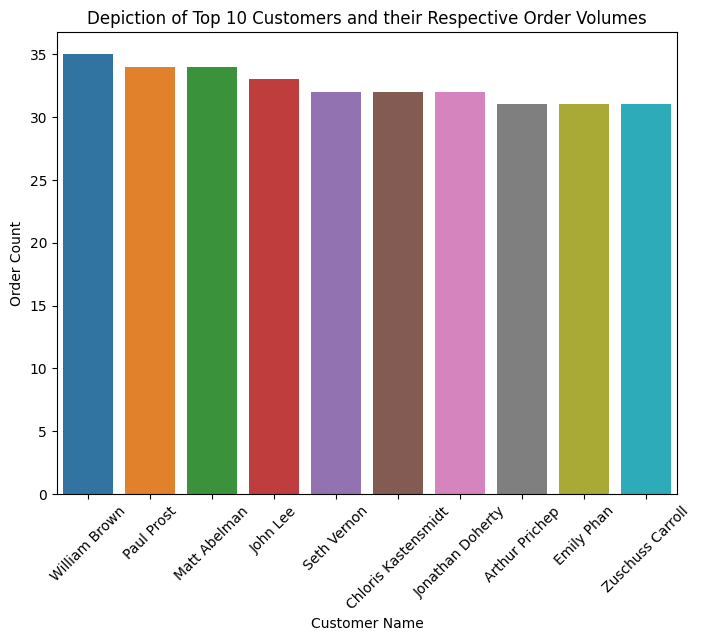

In [20]:
customerorders = sales.groupby(['customer_name', 'order_month', 'order_month_name',], as_index=False)['sales'].size().rename(columns = {'size': 'order_count'})

topcustomers = customerorders.groupby('customer_name', as_index = False)['order_count'].sum().sort_values('order_count', ascending = False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data = topcustomers, x= 'customer_name', y ='order_count', hue = 'customer_name')
plt.xlabel('Customer Name')
plt.ylabel('Order Count')
plt.title('Depiction of Top 10 Customers and their Respective Order Volumes')
plt.xticks(rotation =45)


- The top 10 customers typically place above 31 orders, with the highest being 35.
- Increased order frequency due to repeat customers.

Text(0.5, 1.0, 'Order Counts across Months according to Year')

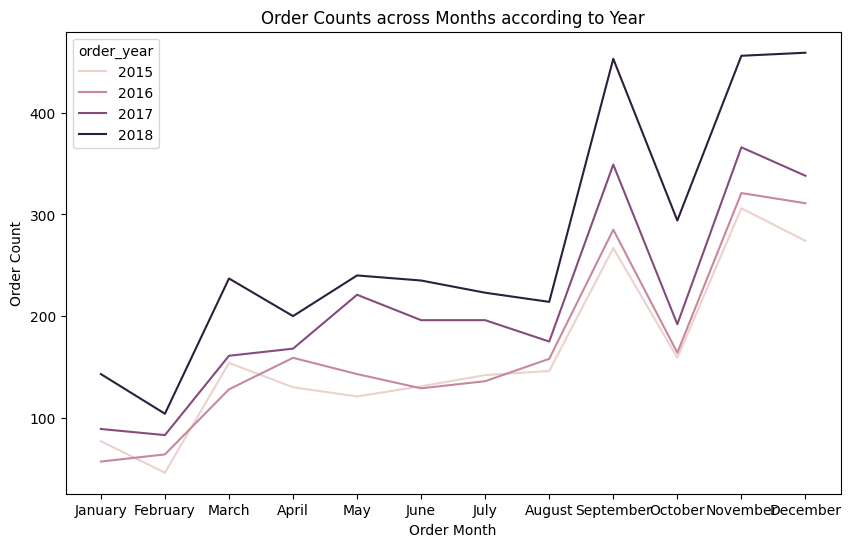

In [21]:
monthly_orders = sales.groupby(['order_month', 'order_month_name', 'order_year'], as_index = False).size().rename(columns={'size':'order_count'}).sort_values('order_month')
sns.lineplot(data = monthly_orders, x = 'order_month_name', y = 'order_count', hue ='order_year')
plt.xlabel('Order Month')
plt.ylabel('Order Count')
plt.title('Order Counts across Months according to Year')

- All years follow a similar trend with sales increasing in March then dropping.
- Sales increase exponentially in September, decrease dramatically in October before increasing in November/December.
- March, September and November generate highest amount of sales.

Text(0.5, 1.0, 'Sales According to Segment')

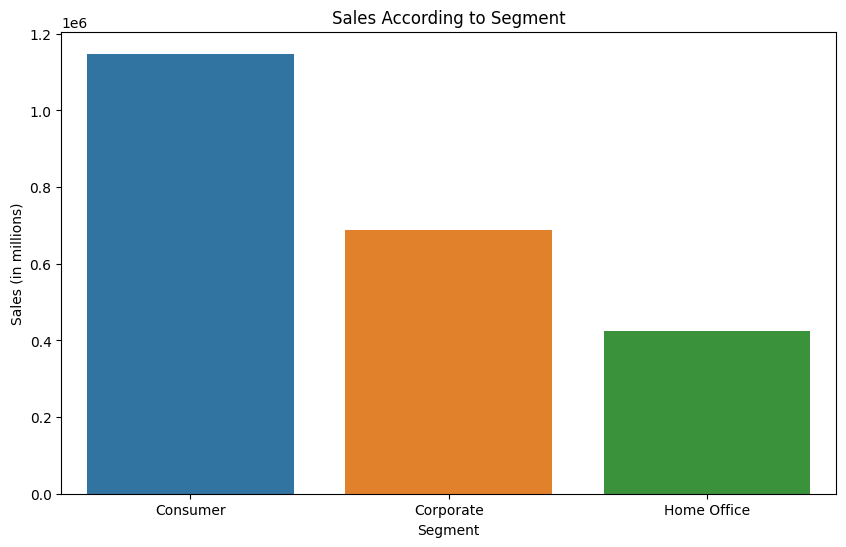

In [24]:
segmentsales = sales.groupby('segment', as_index = False)['sales'].sum()
sns.barplot(data = segmentsales, x = 'segment', y = 'sales', hue = 'segment')
plt.xlabel('Segment')
plt.ylabel('Sales (in millions)')
plt.title('Sales According to Segment')

- Consumer segment has highest contribution towards sales, followed by corporate segment and then home office.
- Standard consumer goods generate highest sales, as indicated in previous charts where standard consumer spend is almost identical across regions when excluding extreme outliers.

#Conclusion

This exploratory data analysis (EDA) report has provided crucial, data driven insights that answer key business questions such as top customers, shipping efficiency, sales variance across different regions and performance across different categories.

A key insight that can be drawn is that spend is typically in the range of 200-230 usd across all regions, with little variance as indicated by average sales performance. The significant difference in sales corresponds to the differing frequency in orders across the central, south, west and east regions. Higher order frequencies corresponding to the increased sales is evident within the East and West regions. This may be due to the presence of more customers in these regions, or customers that tend to place repeat orders. In order to drive sales in Central and South region, the business could prioritise marketing expenditure within these regions to increase customer acquisition to increase sales performance. Another factor could be due to supply or staffing issues within these regions. The dataset could be expanded with records of these factors for further analysis of how they could potentially contribute to the difference in sales performance.

Technology is in the most demand in comparison to office supplies and furniture. Office supplies act as low value high frequency essentials. Copiers and machines profit margins must be protected as these contribute towards large value sales. Sale of office supplies can be encouraged by creating bundle offers when purchasing items within the technology category.

Long-term seasonal tracking confirms a massive, highly predictable surge in order volume during the fourth quarter (November and December), dominated heavily by Standard Class shipping. Despite this, average delivery durations remain stable during this peak window, suggesting the logistics department is working at optimal efficiency.

Individual consumers represent the largest purchasing segment by volume. Corporate segment takes second place, most likely due to sales generating a high profit margin. There is a consistent annual sales drop during January and February.